# UNDERSTANDING THE DATASETS
## Data Cleaning 


In [98]:
import pandas as pd
s=pd.read_csv("Data/PEMS-BAY-META.csv")
s

,sensor_id,Fwy,Dir,District,County,City,State_PM,Abs_PM,Latitude,Longitude,Length,Type,Lanes,Name,User_ID_1,User_ID_2,User_ID_3,User_ID_4
0,400649,17,N,4,85,44112.0,9.06,21.613,37.251741,-121.958118,0.850,ML,2,LARK AVE,DT185,L2-N-37-017-00906,998009,417770
1,400715,17,N,4,85,44112.0,9.4,21.953,37.256205,-121.955355,0.245,ML,2,SB 85 rm-n-conn,DT244,L2-N-37-017-00940,998013,417774
2,400240,17,N,4,85,44112.0,9.55,22.103,37.258184,-121.953853,0.535,ML,3,NB 85 rm-n-conn,DT260,L3-N-37-017-00955,998017,420767
3,403329,17,N,4,85,10340.0,10.47,23.023,37.270267,-121.947353,0.510,ML,3,Camden ave rm-n-loop,DTB25,L3-N-37-017-01047,997278,430594
4,400436,17,N,4,85,10340.0,10.57,23.123,37.271687,-121.947037,0.905,ML,3,Camden Ave rm-n-diag,DT267,l3-N-37-017-01057,998021,420772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,400973,237,E,4,85,69084.0,6.18,6.237,37.417801,-121.972288,0.973,ML,3,GREAT AMERICA PKWY,DT852,L3-E-37-237-00618,998245,420562
321,400567,237,E,4,85,68000.0,6.7,6.752,37.418931,-121.962821,0.462,ML,4,N First St,DT193,L4-E-37-237-00670,998232,420414
322,400104,237,E,4,85,68000.0,7.11,7.162,37.419313,-121.955480,0.665,ML,3,NORTH FIRST STREET,DT814,L3-E-37-237-00711,998233,420567
323,400296,237,E,4,85,68000.0,8.03,8.082,37.420359,-121.939150,0.530,ML,3,oppo Zanker Rd rm-w-loop,DT822,L3-E-37-237-00803,998236,420572


In [99]:
s.head(10)

,sensor_id,Fwy,Dir,District,County,City,State_PM,Abs_PM,Latitude,Longitude,Length,Type,Lanes,Name,User_ID_1,User_ID_2,User_ID_3,User_ID_4
0,400649,17,N,4,85,44112.0,9.06,21.613,37.251741,-121.958118,0.850,ML,2,LARK AVE,DT185,L2-N-37-017-00906,998009,417770
1,400715,17,N,4,85,44112.0,9.4,21.953,37.256205,-121.955355,0.245,ML,2,SB 85 rm-n-conn,DT244,L2-N-37-017-00940,998013,417774
2,400240,17,N,4,85,44112.0,9.55,22.103,37.258184,-121.953853,0.535,ML,3,NB 85 rm-n-conn,DT260,L3-N-37-017-00955,998017,420767
3,403329,17,N,4,85,10340.0,10.47,23.023,37.270267,-121.947353,0.510,ML,3,Camden ave rm-n-loop,DTB25,L3-N-37-017-01047,997278,430594
4,400436,17,N,4,85,10340.0,10.57,23.123,37.271687,-121.947037,0.905,ML,3,Camden Ave rm-n-diag,DT267,l3-N-37-017-01057,998021,420772
5,400221,17,N,4,85,10340.0,12.28,24.833,37.293614,-121.937899,0.945,ML,3,Hamilton Ave rm-n-loop,DT754,L3-N-37-017-01228,998025,420777
6,404370,17,N,4,85,10340.0,12.46,25.013,37.296028,-121.939132,1.579,ML,4,Hamilton Ave rm-n-diag,DT909,L4-N-37-017-01246,998029,422458
7,400268,85,N,4,85,68000.0,5.18,5.180,37.255651,-121.858078,0.600,ML,3,SANTA TERESA,DT488,L3-N-37-085-00518,998053,420812
8,401555,85,N,4,85,68000.0,5.23,5.230,37.255657,-121.858984,0.480,ML,3,Santa Teresa rm-n-diag,DT973,L3-N-37-085-00523,998998,420817
9,400052,85,N,4,85,68000.0,6.14,6.140,37.255791,-121.875479,0.555,ML,3,Almaden Expwy,DT490,L3-N-37-085-00614,998057,420822


In [100]:
print(s.shape)

(325, 18)


In [101]:
print(s.columns)

Index(['sensor_id', 'Fwy', 'Dir', 'District', 'County', 'City', 'State_PM',
       'Abs_PM', 'Latitude', 'Longitude', 'Length', 'Type', 'Lanes', 'Name',
       'User_ID_1', 'User_ID_2', 'User_ID_3', 'User_ID_4'],
      dtype='str')


In [102]:
import h5py
with h5py.File("Data/pems-bay.h5") as f:
    print(list(f.keys()))

['speed']


In [103]:
import h5py

with h5py.File("Data/pems-bay.h5", "r") as f:
    speed = f["speed"]

    print("Inside speed:")
    print(list(speed.keys()))

Inside speed:
['axis0', 'axis1', 'block0_items', 'block0_values']


In [104]:
with h5py.File("Data/pems-bay.h5", "r") as f:
    speed = f["speed"]

    for name in speed.keys():
        print(name, speed[name].shape, speed[name].dtype)

axis0 (325,) int64
axis1 (52116,) int64
block0_items (325,) int64
block0_values (52116, 325) float64


In [105]:
with h5py.File("Data/pems-bay.h5", "r") as f:
    speed = f["speed"]

    for name in speed.keys():
        print(name)
        print("shape:", speed[name].shape)
        print("type:", type(speed[name]))
        print()

axis0
shape: (325,)
type: <class 'h5py._hl.dataset.Dataset'>

axis1
shape: (52116,)
type: <class 'h5py._hl.dataset.Dataset'>

block0_items
shape: (325,)
type: <class 'h5py._hl.dataset.Dataset'>

block0_values
shape: (52116, 325)
type: <class 'h5py._hl.dataset.Dataset'>



In [106]:
with h5py.File("Data/pems-bay.h5", "r") as f:
    speed = f["speed"]["block0_values"]

    print(speed[:10, :10])

[[71.4 67.8 70.5 67.4 68.8 66.6 66.8 68.  66.8 69. ]
 [71.6 67.5 70.6 67.5 68.7 66.6 66.8 67.8 66.5 68.2]
 [71.6 67.6 70.2 67.4 68.7 66.1 66.8 67.8 66.2 67.8]
 [71.1 67.5 70.3 68.  68.5 66.7 66.6 67.7 65.9 67.8]
 [71.7 67.8 70.2 68.1 68.4 66.9 66.1 67.7 66.1 67.8]
 [71.2 67.4 70.3 67.5 68.4 66.5 65.3 67.8 66.4 68.1]
 [71.3 67.6 70.1 67.2 68.5 66.8 65.7 67.8 66.7 68.4]
 [70.5 67.6 70.6 68.1 68.4 66.4 66.6 67.8 66.3 68.4]
 [71.5 67.5 70.5 67.6 68.3 66.5 66.4 67.8 66.6 68.3]
 [70.7 67.4 70.5 68.3 68.5 66.1 66.5 67.8 66.7 68.4]]


In [107]:
with h5py.File("Data/pems-bay.h5", "r") as f:
    axis0 = f["speed"]["axis0"][:]

    print(axis0[:20])

[400001 400017 400030 400040 400045 400052 400057 400059 400065 400069
 400073 400084 400085 400088 400096 400097 400100 400104 400109 400122]


### *Details Of The Sensors*

In [108]:
with h5py.File("Data/pems-bay.h5","r") as f:
    axis0 = f["speed"]["axis0"]

    print(axis0[:20])

[400001 400017 400030 400040 400045 400052 400057 400059 400065 400069
 400073 400084 400085 400088 400096 400097 400100 400104 400109 400122]


#### *UNIX TIMESTAMPS*


In [109]:
with h5py.File("Data/pems-bay.h5", "r") as f:
    axis1 = f["speed"]["axis1"][:]

    print(axis1[:20])

[1483228800000000000 1483229100000000000 1483229400000000000
 1483229700000000000 1483230000000000000 1483230300000000000
 1483230600000000000 1483230900000000000 1483231200000000000
 1483231500000000000 1483231800000000000 1483232100000000000
 1483232400000000000 1483232700000000000 1483233000000000000
 1483233300000000000 1483233600000000000 1483233900000000000
 1483234200000000000 1483234500000000000]


In [110]:
print(1483229100000000000-1483228800000000000  )

300000000000


In [111]:
import pandas as pd
with h5py.File("Data/pems-bay.h5","r") as f:
    timestamps = f["speed"]["axis1"][:]

dates = pd.to_datetime(timestamps)
print(dates)

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 00:05:00',
               '2017-01-01 00:10:00', '2017-01-01 00:15:00',
               '2017-01-01 00:20:00', '2017-01-01 00:25:00',
               '2017-01-01 00:30:00', '2017-01-01 00:35:00',
               '2017-01-01 00:40:00', '2017-01-01 00:45:00',
               ...
               '2017-06-30 23:10:00', '2017-06-30 23:15:00',
               '2017-06-30 23:20:00', '2017-06-30 23:25:00',
               '2017-06-30 23:30:00', '2017-06-30 23:35:00',
               '2017-06-30 23:40:00', '2017-06-30 23:45:00',
               '2017-06-30 23:50:00', '2017-06-30 23:55:00'],
              dtype='datetime64[ns]', length=52116, freq=None)


In [112]:
print(dates[0])

2017-01-01 00:00:00


In [113]:
print(dates[-1])

2017-06-30 23:55:00


In [114]:
import h5py

with h5py.File("Data/pems-bay.h5", "r") as f:
    sensor_ids = f["speed"]["axis0"][:]

print(sensor_ids[:10])

[400001 400017 400030 400040 400045 400052 400057 400059 400065 400069]


In [115]:
print(s["sensor_id"].isin(sensor_ids).sum())
print(len(sensor_ids))

325
325


In [116]:
print(s.columns)

Index(['sensor_id', 'Fwy', 'Dir', 'District', 'County', 'City', 'State_PM',
       'Abs_PM', 'Latitude', 'Longitude', 'Length', 'Type', 'Lanes', 'Name',
       'User_ID_1', 'User_ID_2', 'User_ID_3', 'User_ID_4'],
      dtype='str')


In [117]:
s.shape[0]  

325

In [118]:
import h5py
with h5py.File('Data/pems-bay.h5','r') as f:
    speed = f["speed"]["block0_values"][:]
    sensor_ids = f["speed"]["axis0"][:]
    timestamps = f["speed"]["axis1"][:]
print("Speed shape:", speed.shape)
print("Sensors:", len(sensor_ids))
print("Time steps:", len(timestamps))


Speed shape: (52116, 325)
Sensors: 325
Time steps: 52116


In [119]:
with h5py.File("Data/pems-bay.h5", "r") as f:

    print("=== SENSOR IDs ===")
    print(f["speed"]["axis0"][:10])

    print("\n=== TIMESTAMPS ===")
    print(f["speed"]["axis1"][:10])

    print("\n=== TRAFFIC SPEEDS ===")
    print(f["speed"]["block0_values"][:10, :10])

=== SENSOR IDs ===
[400001 400017 400030 400040 400045 400052 400057 400059 400065 400069]

=== TIMESTAMPS ===
[1483228800000000000 1483229100000000000 1483229400000000000
 1483229700000000000 1483230000000000000 1483230300000000000
 1483230600000000000 1483230900000000000 1483231200000000000
 1483231500000000000]

=== TRAFFIC SPEEDS ===
[[71.4 67.8 70.5 67.4 68.8 66.6 66.8 68.  66.8 69. ]
 [71.6 67.5 70.6 67.5 68.7 66.6 66.8 67.8 66.5 68.2]
 [71.6 67.6 70.2 67.4 68.7 66.1 66.8 67.8 66.2 67.8]
 [71.1 67.5 70.3 68.  68.5 66.7 66.6 67.7 65.9 67.8]
 [71.7 67.8 70.2 68.1 68.4 66.9 66.1 67.7 66.1 67.8]
 [71.2 67.4 70.3 67.5 68.4 66.5 65.3 67.8 66.4 68.1]
 [71.3 67.6 70.1 67.2 68.5 66.8 65.7 67.8 66.7 68.4]
 [70.5 67.6 70.6 68.1 68.4 66.4 66.6 67.8 66.3 68.4]
 [71.5 67.5 70.5 67.6 68.3 66.5 66.4 67.8 66.6 68.3]
 [70.7 67.4 70.5 68.3 68.5 66.1 66.5 67.8 66.7 68.4]]


### TRYING TO MAP THE SENSORS IDS TO THE TRAFFIC SPEEDS



In [120]:
with h5py.File("Data/pems-bay.h5","r") as f:
    print("===Sensor_id====")
    print(f["speed"]["axis1"][:10])
    print(f["speed"]["block0_values"][:10, :10])

===Sensor_id====
[1483228800000000000 1483229100000000000 1483229400000000000
 1483229700000000000 1483230000000000000 1483230300000000000
 1483230600000000000 1483230900000000000 1483231200000000000
 1483231500000000000]
[[71.4 67.8 70.5 67.4 68.8 66.6 66.8 68.  66.8 69. ]
 [71.6 67.5 70.6 67.5 68.7 66.6 66.8 67.8 66.5 68.2]
 [71.6 67.6 70.2 67.4 68.7 66.1 66.8 67.8 66.2 67.8]
 [71.1 67.5 70.3 68.  68.5 66.7 66.6 67.7 65.9 67.8]
 [71.7 67.8 70.2 68.1 68.4 66.9 66.1 67.7 66.1 67.8]
 [71.2 67.4 70.3 67.5 68.4 66.5 65.3 67.8 66.4 68.1]
 [71.3 67.6 70.1 67.2 68.5 66.8 65.7 67.8 66.7 68.4]
 [70.5 67.6 70.6 68.1 68.4 66.4 66.6 67.8 66.3 68.4]
 [71.5 67.5 70.5 67.6 68.3 66.5 66.4 67.8 66.6 68.3]
 [70.7 67.4 70.5 68.3 68.5 66.1 66.5 67.8 66.7 68.4]]


In [121]:
from sklearn.model_selection import train_test_split
with h5py.File("Data/pems-bay.h5","r") as f:
    
    X = f["speed"]["axis1"][:10]
    

#X_train,X_test,y_train,y_test = train_test_split()

In [122]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
speed_scaled = scaler.fit_transform(speed)
print(speed_scaled)

[[0.47190633 0.66270851 0.97451836 ... 0.88257855 0.53087153 0.43422383]
 [0.49653968 0.64006709 0.98309579 ... 0.79843607 0.48838311 0.3632675 ]
 [0.49653968 0.64761423 0.94878606 ... 0.79843607 0.44589469 0.42239777]
 ...
 [0.47190633 0.59478425 0.76865998 ... 0.79843607 0.60168556 0.26865905]
 [0.57043971 0.56459568 0.76008255 ... 0.86154293 0.60168556 0.48152805]
 [0.48422301 0.54195426 0.79439228 ... 0.86154293 0.60168556 0.43422383]]


In [123]:
train_size = int(len(speed_scaled) * 0.70)
val_size = int(len(speed_scaled) * 0.15)

train = speed_scaled[:train_size]

val = speed_scaled[train_size:train_size + val_size]

test = speed_scaled[train_size + val_size:]

print(train.shape)
print(val.shape)
print(test.shape)

(36481, 325)
(7817, 325)
(7818, 325)


In [124]:
import numpy as np
sequence_length = 12
X = []
y = []

for i in range(len(speed) - sequence_length):
    X.append(speed[i:i + sequence_length])
    y.append(speed[i + sequence_length])
X = np.array(X)
y = np.array(y)

print(len(X))
print("---for Y ----")
print(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

52104
---for Y ----
[[71.  67.2 70.3 ... 68.3 71.1 67.9]
 [71.3 67.9 70.1 ... 68.3 71.2 67.7]
 [71.6 67.6 70.3 ... 68.2 70.8 67.4]
 ...
 [71.4 66.9 68.1 ... 68.4 71.6 66.6]
 [72.2 66.5 68.  ... 68.7 71.6 68.4]
 [71.5 66.2 68.4 ... 68.7 71.6 68. ]]
X shape: (52104, 12, 325)
y shape: (52104, 325)


In [125]:
# Split raw traffic speed data chronologically

train_size = int(len(speed) * 0.70)
val_size = int(len(speed) * 0.15)

speed_train = speed[:train_size]
speed_val = speed[train_size:train_size + val_size]
speed_test = speed[train_size + val_size:]

print("Train:", speed_train.shape)
print("Validation:", speed_val.shape)
print("Test:", speed_test.shape)

Train: (36481, 325)
Validation: (7817, 325)
Test: (7818, 325)


In [126]:
scaler = StandardScaler()
speed_scaled = scaler.fit_transform(speed)

In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
speed_train_scaled = scaler.fit_transform(speed_train)

# Use the same scaler for validation and test
speed_val_scaled = scaler.transform(speed_val)
speed_test_scaled = scaler.transform(speed_test)

print("Scaled train:", speed_train_scaled.shape)
print("Scaled validation:", speed_val_scaled.shape)
print("Scaled test:", speed_test_scaled.shape)

Scaled train: (36481, 325)
Scaled validation: (7817, 325)
Scaled test: (7818, 325)


## DeepLearning Started
### Checking the necessary components





In [128]:
import torch 
#CUDA (Compute Unified Device Architecture)
print("CUDA Running Status :",torch.cuda.is_available())
if (torch.cuda.is_available() == True):
    print(torch.cuda.get_device_name(0))
else:
    print('Not detected')

CUDA Running Status : True
NVIDIA GeForce RTX 4060 Laptop GPU


In [129]:
x = torch.randn(10000, 10000)
y = torch.randn(10000, 10000)

z = x @ y
print(z)

tensor([[ 121.9251,  -17.5396,  -82.3117,  ...,  -69.4212,   -2.7889,
           41.4292],
        [  51.7892,   45.6352,  -58.1629,  ...,    3.2947,  -78.9783,
          290.1888],
        [ 168.0946,   30.3354,   81.3986,  ...,  -91.6200,  167.8605,
           14.0253],
        ...,
        [  51.0905,  -73.9337,  -74.2650,  ...,  -43.2629,  -45.6584,
          -86.3749],
        [ -90.8684,  116.4901,  -61.8665,  ...,  -84.9995,  -21.5365,
         -159.4243],
        [ 105.7449, -125.6460, -116.3050,  ...,   19.3246,  -61.6624,
           85.9585]])


In [130]:
def create_sequences(data, sequence_length=12):
    X = []
    y = []

    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])

    return np.array(X), np.array(y)


sequence_length = 12

X_train, y_train = create_sequences(
    speed_train_scaled,
    sequence_length
)

X_val, y_val = create_sequences(
    speed_val_scaled,
    sequence_length
)

X_test, y_test = create_sequences(
    speed_test_scaled,
    sequence_length
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (36469, 12, 325)
y_train: (36469, 325)
X_val: (7805, 12, 325)
y_val: (7805, 325)
X_test: (7806, 12, 325)
y_test: (7806, 325)


## Converting the inputs to tensors


In [131]:
import torch

x_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

x_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

x_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_val:", x_val.shape)
print("y_val:", y_val.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: torch.Size([36469, 12, 325])
y_train: torch.Size([36469, 325])
x_val: torch.Size([7805, 12, 325])
y_val: torch.Size([7805, 325])
x_test: torch.Size([7806, 12, 325])
y_test: torch.Size([7806, 325])


### 
TRAINING LSTM


In [132]:
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 570
Validation batches: 122
Test batches: 122


In [133]:
import torch
import torch.nn as nn

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(
    input_size=325,
    hidden_size=64,
    output_size=325
).to(device)

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 20

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):

    # -------------------------
    # TRAINING
    # -------------------------
    model.train()

    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = loss_function(predictions, y_batch)

        loss.backward()

        # Prevent excessively large gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_train_loss += loss.item()

    average_train_loss = total_train_loss / len(train_loader)

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    total_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = loss_function(predictions, y_batch)

            total_val_loss += loss.item()

    average_val_loss = total_val_loss / len(val_loader)

    train_losses.append(average_train_loss)
    val_losses.append(average_val_loss)

    # Save best model
    if average_val_loss < best_val_loss:

        best_val_loss = average_val_loss

        torch.save(
            model.state_dict(),
            "best_lstm_model.pth"
        )

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Val Loss: {average_val_loss:.4f}"
    )

Epoch 1/20 | Train Loss: 0.4263 | Val Loss: 0.4336
Epoch 2/20 | Train Loss: 0.3152 | Val Loss: 0.3907
Epoch 3/20 | Train Loss: 0.2830 | Val Loss: 0.3682
Epoch 4/20 | Train Loss: 0.2622 | Val Loss: 0.3566
Epoch 5/20 | Train Loss: 0.2456 | Val Loss: 0.3415
Epoch 6/20 | Train Loss: 0.2316 | Val Loss: 0.3308
Epoch 7/20 | Train Loss: 0.2199 | Val Loss: 0.3195
Epoch 8/20 | Train Loss: 0.2107 | Val Loss: 0.3163
Epoch 9/20 | Train Loss: 0.2038 | Val Loss: 0.3154
Epoch 10/20 | Train Loss: 0.1968 | Val Loss: 0.3047
Epoch 11/20 | Train Loss: 0.1896 | Val Loss: 0.2994
Epoch 12/20 | Train Loss: 0.1846 | Val Loss: 0.2968
Epoch 13/20 | Train Loss: 0.1807 | Val Loss: 0.2965
Epoch 14/20 | Train Loss: 0.1774 | Val Loss: 0.2852
Epoch 15/20 | Train Loss: 0.1737 | Val Loss: 0.2845
Epoch 16/20 | Train Loss: 0.1706 | Val Loss: 0.2862
Epoch 17/20 | Train Loss: 0.1674 | Val Loss: 0.2767
Epoch 18/20 | Train Loss: 0.1655 | Val Loss: 0.2788
Epoch 19/20 | Train Loss: 0.1631 | Val Loss: 0.2773
Epoch 20/20 | Train L

In [140]:
model = LSTMModel(
    input_size=325,
    hidden_size=64,
    output_size=325
).to(device)

model.load_state_dict(
    torch.load(
        "best_lstm_model.pth",
        map_location=device
    )
)

model.eval()

print("Best LSTM model loaded successfully.")

Best LSTM model loaded successfully.


In [135]:
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## Model Evalutation

In [141]:
model.eval()

predictions_list = []
targets_list = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = model(X_batch)

        predictions_list.append(
            predictions.cpu().numpy()
        )

        targets_list.append(
            y_batch.cpu().numpy()
        )

predictions_scaled = np.concatenate(
    predictions_list,
    axis=0
)

targets_scaled = np.concatenate(
    targets_list,
    axis=0
)

print("Predictions shape:", predictions_scaled.shape)
print("Actual shape:", targets_scaled.shape)

Predictions shape: (7806, 325)
Actual shape: (7806, 325)


In [142]:
# Convert scaled predictions and targets back to original speed values

predictions = scaler.inverse_transform(predictions_scaled)
targets = scaler.inverse_transform(targets_scaled)

print("Predictions shape:", predictions.shape)
print("Actual shape:", targets.shape)

Predictions shape: (7806, 325)
Actual shape: (7806, 325)


In [143]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    targets,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        targets,
        predictions
    )
)

print("Test MAE:", mae)
print("Test RMSE:", rmse)

Test MAE: 2.5304808616638184
Test RMSE: 4.224936463369223


## GRAPHICAL ANALYSIS

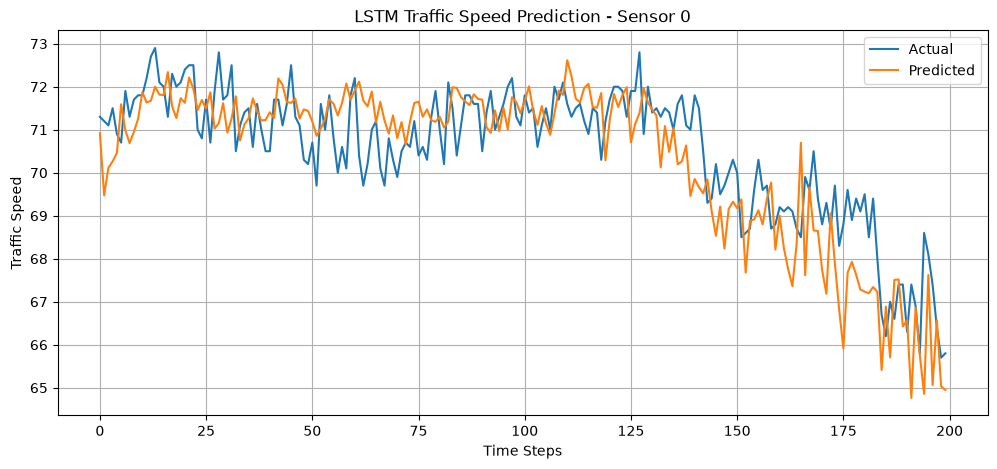

In [145]:
import matplotlib.pyplot as plt

# Select one sensor
sensor = 0

plt.figure(figsize=(12, 5))

plt.plot(
    targets[:200, sensor],
    label="Actual"
)

plt.plot(
    predictions[:200, sensor],
    label="Predicted"
)

plt.xlabel("Time Steps")
plt.ylabel("Traffic Speed")

plt.title(
    f"LSTM Traffic Speed Prediction - Sensor {sensor}"
)

plt.legend()
plt.grid(True)

plt.show()

In [146]:
train_size = int(len(speed) * 0.70)
val_size = int(len(speed) * 0.15)

speed_train = speed[:train_size]
speed_val = speed[train_size:train_size + val_size]
speed_test = speed[train_size + val_size:]

print("Train:", speed_train.shape)
print("Validation:", speed_val.shape)
print("Test:", speed_test.shape)

Train: (36481, 325)
Validation: (7817, 325)
Test: (7818, 325)


In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

speed_train_scaled = scaler.fit_transform(speed_train)

speed_val_scaled = scaler.transform(speed_val)

speed_test_scaled = scaler.transform(speed_test)

print(speed_train_scaled.shape)
print(speed_val_scaled.shape)
print(speed_test_scaled.shape)

(36481, 325)
(7817, 325)
(7818, 325)
